# Midstance Ground Detection — Test Notebook

**Dataset:** `Kristian_dry_0425.csv`  
**Algorithm:** Minimum Normalised Heel/Forefoot Difference  

This notebook:
1. Loads and preprocesses the new dataset
2. Runs the midstance detection pipeline on both feet
3. Computes detection accuracy using physiological heuristics
4. Visualises results as an accuracy dashboard, pressure heatmaps, and quality-over-time plots
5. Runs all integration test cases from the test suite


## 0. Imports & Test Runner

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.signal import find_peaks, savgol_filter
import warnings; warnings.filterwarnings('ignore')

_results = []

def run_test(name, fn):
    try:
        fn()
        _results.append((name, True, None))
        print(f'  ✅  {name}')
    except Exception as e:
        _results.append((name, False, str(e)))
        print(f'  ❌  {name}')
        print(f'       {e}')

def section(title):
    print(f'\n{"-"*55}')
    print(f'  {title}')
    print(f'{"-"*55}')

def summary():
    passed = sum(1 for _, ok, _ in _results if ok)
    total  = len(_results)
    print(f'\n{"="*55}')
    print(f'  Results: {passed}/{total} passed')
    if passed < total:
        print('  Failed:')
        for name, ok, err in _results:
            if not ok:
                print(f'    ❌ {name}: {err}')
    print(f'{"="*55}')

print('Imports ready.')

Imports ready.


## 1. Constants & Pipeline Functions

In [2]:
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]

SMOOTH_WIN = 11; SMOOTH_POLY = 2
BIG_PEAK_DIST = 50; BIG_PEAK_PROM = 200; BIG_PEAK_HT = 500

# Detection quality thresholds
DIFF_THR = 40   # max ADC balance difference for a 'good' midstance
MIN_INT  = 0.4  # min plausible step interval (s)
MAX_INT  = 2.5  # max plausible step interval (s)

# Stappone 12-sensor layout: (row=front->back, col=lat->med)
SENSOR_GRID = {
    'pressure_01': (0,1), 'pressure_02': (0,2),
    'pressure_03': (1,0), 'pressure_04': (1,1),
    'pressure_05': (1,2), 'pressure_06': (1,3),
    'pressure_07': (2,0), 'pressure_08': (2,1),
    'pressure_09': (2,2),
    'pressure_10': (3,0), 'pressure_11': (3,1), 'pressure_12': (3,2),
}
GRID_ROWS, GRID_COLS = 4, 4

In [3]:
def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df

def extract_midstance_pressure(
    df, surface_label='unknown', foot_label='unknown', time_col='time_sec',
    heel_sensors=None, forefoot_sensors=None,
    smooth_win=11, smooth_poly=2, peak_dist=50, peak_prom=200, peak_ht=500,
):
    if heel_sensors is None: heel_sensors = HEEL_SENSORS
    if forefoot_sensors is None: forefoot_sensors = FOREFOOT_SENSORS
    df = df.copy().reset_index(drop=True)
    heel_cols = [c for c in heel_sensors if c in df.columns]
    fore_cols = [c for c in forefoot_sensors if c in df.columns]
    n_heel, n_fore = len(heel_cols), len(fore_cols)
    heel_sig  = df[heel_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).values
    fore_sig  = df[fore_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).values
    heel_norm = heel_sig / max(n_heel, 1)
    fore_norm = fore_sig / max(n_fore, 1)
    n = len(heel_sig)
    sw = min(smooth_win, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= smooth_poly: sw = smooth_poly+3+(1 if (smooth_poly+3)%2==0 else 0)
    y_sm = savgol_filter(heel_sig, window_length=sw, polyorder=min(smooth_poly, sw-1))
    big_peaks, _ = find_peaks(y_sm, distance=peak_dist, prominence=peak_prom, height=peak_ht)
    if len(big_peaks) < 2: return pd.DataFrame(), big_peaks
    results = []
    for i in range(len(big_peaks) - 1):
        p1, p2 = big_peaks[i], big_peaks[i+1]
        c_idx  = p1 + int(np.argmin(heel_sig[p1:p2]))
        diff   = np.abs(heel_norm[c_idx:p2] - fore_norm[c_idx:p2])
        mid_idx = c_idx + int(np.argmin(diff))
        row = {
            'surface': surface_label, 'foot': foot_label, 'step_id': i+1,
            'contact_time_sec': float(df[time_col].iloc[c_idx]),
            'midstance_time_sec': float(df[time_col].iloc[mid_idx]),
            'midstance_heel': float(heel_norm[mid_idx]),
            'midstance_forefoot': float(fore_norm[mid_idx]),
            'midstance_difference': float(diff[mid_idx - c_idx]),
            'peak1_idx': int(p1), 'peak2_idx': int(p2),
        }
        for s in ALL_SENSORS:
            if s in df.columns:
                row[f'mid_{s}'] = float(pd.to_numeric(df[s], errors='coerce').iloc[mid_idx])
        results.append(row)
    return pd.DataFrame(results), big_peaks

print('Functions defined.')

Functions defined.


## 2. Load & Preprocess — Kristian Dry 04/25

In [4]:
raw = pd.read_csv('Kristian_dry_0425.csv', low_memory=False)
print(f'Total rows : {len(raw)}')
print(f'Sole IDs   : {sorted(raw["sole_id"].unique())}')

all_results = {}
for sole_id, foot in [(1, 'right'), (2, 'left')]:
    df = preprocess(raw[raw['sole_id'] == sole_id])
    mid_df, peaks = extract_midstance_pressure(
        df, surface_label='dry', foot_label=foot)

    # Quality flags
    intervals = np.diff(mid_df['contact_time_sec'].values)
    intervals = np.append(intervals, np.nan)
    mid_df['step_interval_sec'] = intervals
    plausible = ((mid_df['step_interval_sec'].fillna(1.0) >= MIN_INT) &
                 (mid_df['step_interval_sec'].fillna(1.0) <= MAX_INT))
    balanced  = mid_df['midstance_difference'] <= DIFF_THR
    mid_df['well_detected'] = plausible & balanced
    mid_df['flag_interval'] = ~plausible
    mid_df['flag_balance']  = ~balanced & plausible
    all_results[foot] = (df, mid_df, peaks)
    print(f'\n{foot.upper()} (sole_id={sole_id}): {len(df)} rows | '
          f'{df["time_sec"].iloc[-1]:.1f}s | {len(peaks)} peaks -> {len(mid_df)} steps')

Total rows : 51267
Sole IDs   : [np.int64(1), np.int64(2)]

RIGHT (sole_id=1): 25633 rows | 410.1s | 347 peaks -> 346 steps

LEFT (sole_id=2): 25634 rows | 410.1s | 348 peaks -> 347 steps


## 3. Detection Accuracy

A step is classified as **well-detected** if:
- `midstance_difference ≤ 40` ADC units (heel and forefoot are balanced)
- `step_interval ∈ [0.4, 2.5]` s (physiologically plausible cadence)

Steps failing either criterion are flagged as **bad interval** or **imbalanced**.

In [5]:
print(f'{'─'*50}')
print(f'  Detection Accuracy Summary')
print(f'{'─'*50}')
for foot, (df, mid_df, peaks) in all_results.items():
    n    = len(mid_df)
    wd   = mid_df['well_detected'].sum()
    bi   = mid_df['flag_interval'].sum()
    bb   = mid_df['flag_balance'].sum()
    acc  = wd / n * 100
    print(f'  {foot.upper()} FOOT:')
    print(f'    Total steps       : {n}')
    print(f'    Well-detected (TP): {wd}  ({acc:.1f}%)')
    print(f'    Bad interval      : {bi}')
    print(f'    Imbalanced only   : {bb}')
    print()

──────────────────────────────────────────────────
  Detection Accuracy Summary
──────────────────────────────────────────────────
  RIGHT FOOT:
    Total steps       : 346
    Well-detected (TP): 344  (99.4%)
    Bad interval      : 2
    Imbalanced only   : 0

  LEFT FOOT:
    Total steps       : 347
    Well-detected (TP): 341  (98.3%)
    Bad interval      : 2
    Imbalanced only   : 4



## 4. Accuracy Dashboard

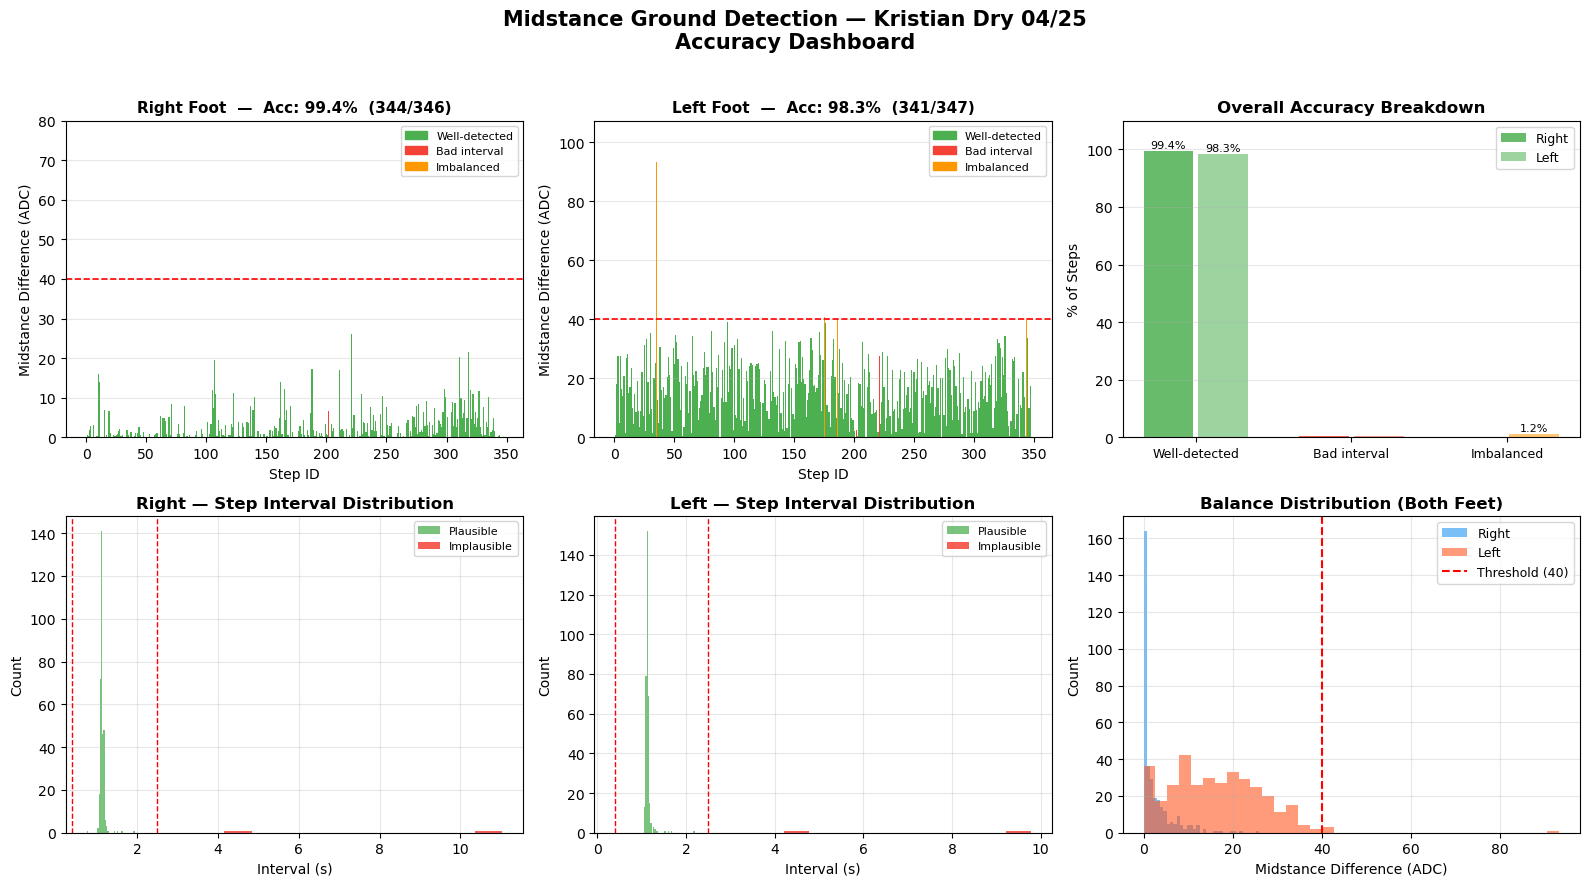

In [6]:
COLORS = {'right': '#2196F3', 'left': '#FF5722'}
FOOT_LABELS = ['right', 'left']

fig1, axes = plt.subplots(2, 3, figsize=(16, 9))
fig1.suptitle('Midstance Ground Detection — Kristian Dry 04/25\nAccuracy Dashboard',
              fontsize=15, fontweight='bold', y=0.98)

for col_idx, foot in enumerate(FOOT_LABELS):
    ax = axes[0, col_idx]
    _, mid_df, _ = all_results[foot]
    colors = ['#4CAF50' if w else ('#F44336' if fi else '#FF9800')
              for w, fi in zip(mid_df['well_detected'], mid_df['flag_interval'])]
    ax.bar(mid_df['step_id'], mid_df['midstance_difference'],
           color=colors, width=1.0, linewidth=0)
    ax.axhline(DIFF_THR, color='red', lw=1.2, ls='--', label=f'Threshold ({DIFF_THR})')
    acc = mid_df['well_detected'].sum() / len(mid_df) * 100
    ax.set_title(f'{foot.capitalize()} Foot  —  Acc: {acc:.1f}%  ({mid_df["well_detected"].sum()}/{len(mid_df)})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Step ID'); ax.set_ylabel('Midstance Difference (ADC)')
    ax.legend(handles=[
        mpatches.Patch(color='#4CAF50', label='Well-detected'),
        mpatches.Patch(color='#F44336', label='Bad interval'),
        mpatches.Patch(color='#FF9800', label='Imbalanced'),
    ], fontsize=8, loc='upper right')
    ax.set_ylim(0, max(DIFF_THR*2, mid_df['midstance_difference'].max()*1.15))
    ax.grid(axis='y', alpha=0.3)

ax = axes[0, 2]
categories = ['Well-detected', 'Bad interval', 'Imbalanced']
for i, foot in enumerate(FOOT_LABELS):
    _, mid_df, _ = all_results[foot]
    vals = [mid_df['well_detected'].sum(), mid_df['flag_interval'].sum(), mid_df['flag_balance'].sum()]
    pcts = [v / len(mid_df) * 100 for v in vals]
    x = np.arange(3) + i * 0.35
    bars = ax.bar(x, pcts, width=0.32, color=['#4CAF50','#F44336','#FF9800'],
                  alpha=0.85 if foot=='right' else 0.55, label=foot.capitalize())
    for bar, pct in zip(bars, pcts):
        if pct > 1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(np.arange(3)+0.175); ax.set_xticklabels(categories, fontsize=9)
ax.set_ylabel('% of Steps'); ax.set_title('Overall Accuracy Breakdown', fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 110); ax.grid(axis='y', alpha=0.3)

for col_idx, foot in enumerate(FOOT_LABELS):
    ax = axes[1, col_idx]
    _, mid_df, _ = all_results[foot]
    intervals = mid_df['step_interval_sec'].dropna()
    ax.hist(intervals[(intervals>=MIN_INT)&(intervals<=MAX_INT)], bins=40,
            color='#4CAF50', alpha=0.75, label='Plausible')
    ax.hist(intervals[(intervals<MIN_INT)|(intervals>MAX_INT)], bins=10,
            color='#F44336', alpha=0.85, label='Implausible')
    ax.axvline(MIN_INT, color='red', ls='--', lw=1)
    ax.axvline(MAX_INT, color='red', ls='--', lw=1)
    ax.set_title(f'{foot.capitalize()} — Step Interval Distribution', fontweight='bold')
    ax.set_xlabel('Interval (s)'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 2]
for foot in FOOT_LABELS:
    _, mid_df, _ = all_results[foot]
    ax.hist(mid_df['midstance_difference'], bins=35, alpha=0.6,
            color=COLORS[foot], label=foot.capitalize())
ax.axvline(DIFF_THR, color='red', ls='--', lw=1.5, label=f'Threshold ({DIFF_THR})')
ax.set_title('Balance Distribution (Both Feet)', fontweight='bold')
ax.set_xlabel('Midstance Difference (ADC)'); ax.set_ylabel('Count')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

## 5. Pressure Heatmap — Foot Sole View

Mean ADC pressure at midstance per sensor, displayed on the anatomical sole layout.  
**Blue border** = heel sensors | **Green border** = forefoot sensors used in the balance metric.

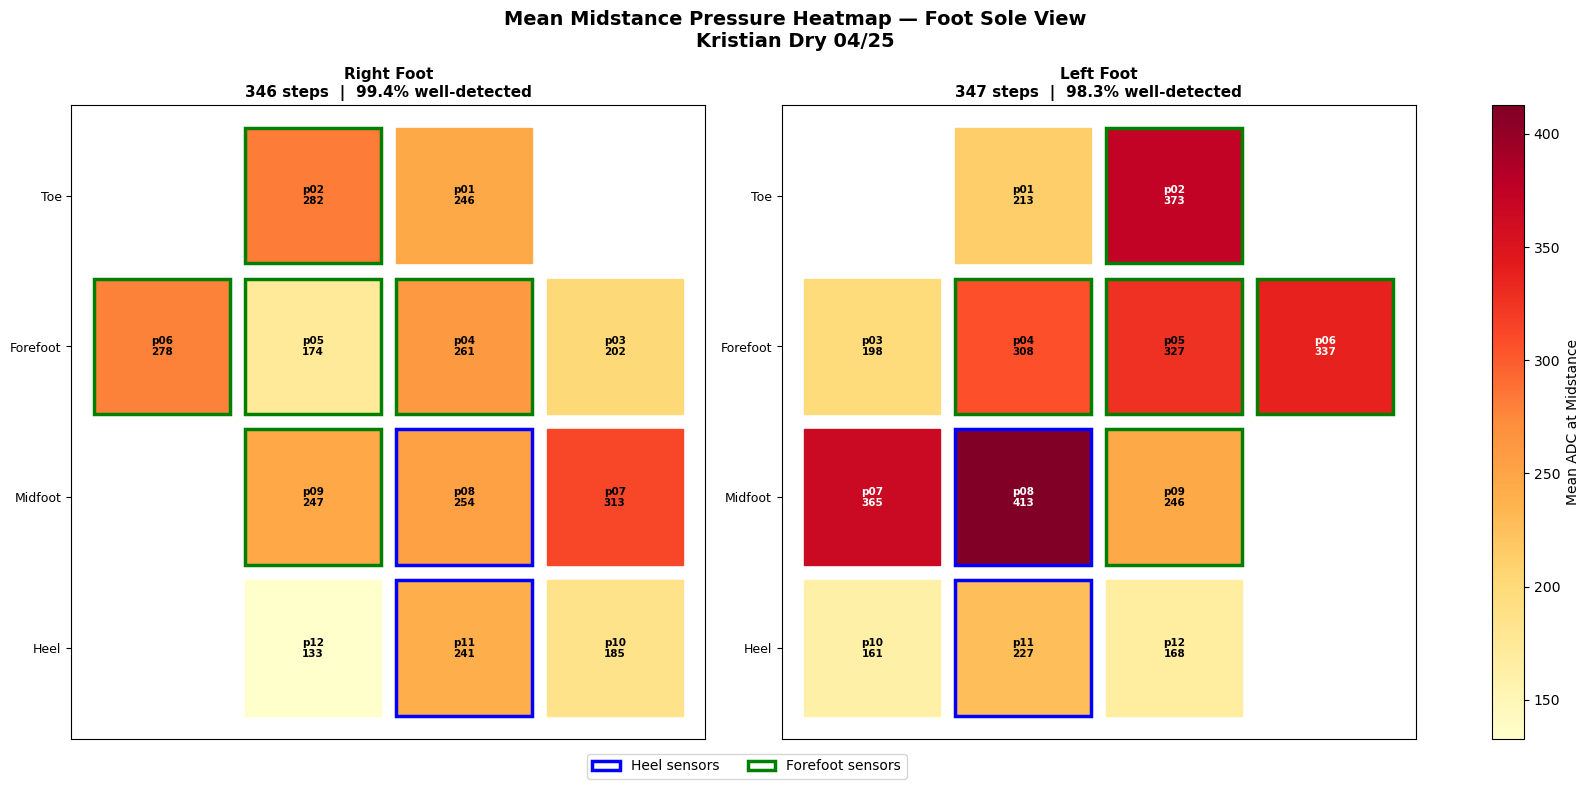

In [7]:
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 8),
                            gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig2.suptitle('Mean Midstance Pressure Heatmap — Foot Sole View\nKristian Dry 04/25',
              fontsize=14, fontweight='bold')

all_vals = []
for foot in FOOT_LABELS:
    _, mid_df, _ = all_results[foot]
    for s in ALL_SENSORS:
        if f'mid_{s}' in mid_df.columns: all_vals.append(mid_df[f'mid_{s}'].mean())
vmin, vmax = min(all_vals), max(all_vals)
cmap = plt.cm.YlOrRd
norm = Normalize(vmin=vmin, vmax=vmax)

for col_idx, foot in enumerate(FOOT_LABELS):
    ax = axes2[col_idx]
    _, mid_df, _ = all_results[foot]
    for s, (r, c) in SENSOR_GRID.items():
        draw_c = (GRID_COLS-1-c) if foot=='right' else c
        val = mid_df[f'mid_{s}'].mean() if f'mid_{s}' in mid_df.columns else float('nan')
        color = cmap(norm(val)) if not (val!=val) else '#ccc'
        ax.add_patch(plt.Rectangle((draw_c-0.45,(GRID_ROWS-1-r)-0.45),
                                    0.9, 0.9, color=color, zorder=2))
        ax.text(draw_c, GRID_ROWS-1-r, f"{s.replace('pressure_','p')}\n{val:.0f}",
                ha='center', va='center', fontsize=7.5, fontweight='bold',
                color='black' if val < vmin+(vmax-vmin)*0.7 else 'white', zorder=3)
    for s in HEEL_SENSORS:
        r, c = SENSOR_GRID[s]; draw_c = (GRID_COLS-1-c) if foot=='right' else c
        ax.add_patch(plt.Rectangle((draw_c-0.45,(GRID_ROWS-1-r)-0.45),
                                    0.9, 0.9, fill=False, edgecolor='blue', lw=2.5, zorder=4))
    for s in FOREFOOT_SENSORS:
        r, c = SENSOR_GRID[s]; draw_c = (GRID_COLS-1-c) if foot=='right' else c
        ax.add_patch(plt.Rectangle((draw_c-0.45,(GRID_ROWS-1-r)-0.45),
                                    0.9, 0.9, fill=False, edgecolor='green', lw=2.5, zorder=4))
    ax.set_xlim(-0.6, GRID_COLS-0.4); ax.set_ylim(-0.6, GRID_ROWS-0.4)
    ax.set_aspect('equal'); ax.set_xticks([])
    ax.set_yticks([0,1,2,3])
    ax.set_yticklabels(['Heel','Midfoot','Forefoot','Toe'], fontsize=9)
    n_steps = len(mid_df)
    acc = mid_df['well_detected'].sum()/n_steps*100
    ax.set_title(f'{foot.capitalize()} Foot\n{n_steps} steps  |  {acc:.1f}% well-detected',
                 fontweight='bold', fontsize=11)

sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cb = fig2.colorbar(sm, cax=axes2[2]); cb.set_label('Mean ADC at Midstance', fontsize=10)
fig2.legend(handles=[
    mpatches.Patch(edgecolor='blue',  facecolor='none', lw=2.5, label='Heel sensors'),
    mpatches.Patch(edgecolor='green', facecolor='none', lw=2.5, label='Forefoot sensors'),
], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.47,0.01))
plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()

## 6. Detection Quality Over Time

Each dot = one step. Colour = midstance balance difference (green=good, red=poor).  
Black ✕ = steps with implausible step interval.

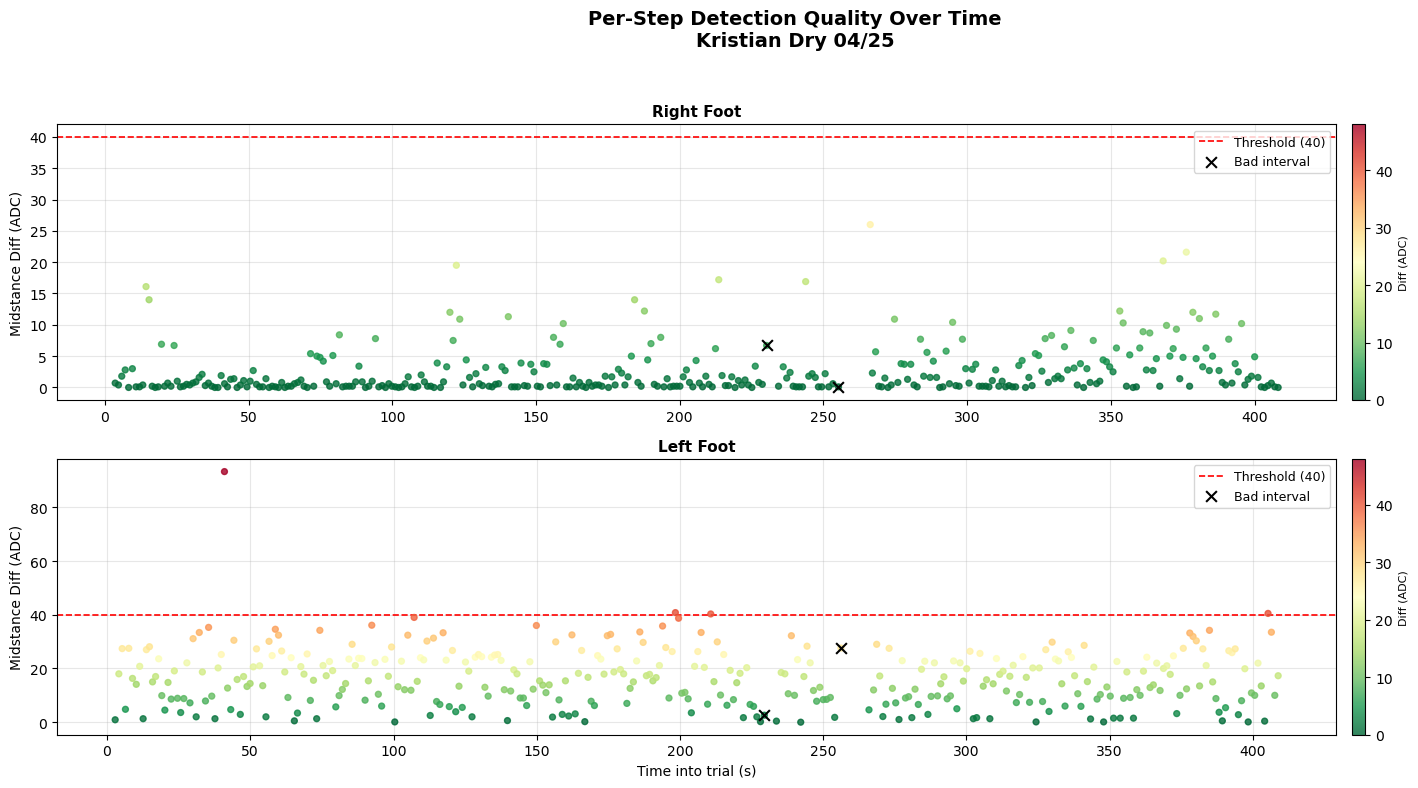

In [8]:
fig3, axes3 = plt.subplots(2, 1, figsize=(16, 8), sharex=False)
fig3.suptitle('Per-Step Detection Quality Over Time\nKristian Dry 04/25',
              fontsize=14, fontweight='bold')

for row_idx, foot in enumerate(FOOT_LABELS):
    ax = axes3[row_idx]
    _, mid_df, _ = all_results[foot]
    sc = ax.scatter(mid_df['contact_time_sec'], mid_df['midstance_difference'],
                    c=mid_df['midstance_difference'],
                    cmap='RdYlGn_r', vmin=0, vmax=DIFF_THR*1.2, s=18, alpha=0.8, zorder=3)
    ax.axhline(DIFF_THR, color='red', ls='--', lw=1.2, label=f'Threshold ({DIFF_THR})')
    bad = mid_df[mid_df['flag_interval']]
    ax.scatter(bad['contact_time_sec'], bad['midstance_difference'],
               marker='x', color='black', s=60, lw=1.5, label='Bad interval', zorder=5)
    ax.set_ylabel('Midstance Diff (ADC)')
    ax.set_title(f'{foot.capitalize()} Foot', fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper right')
    fig3.colorbar(sc, ax=ax, pad=0.01).set_label('Diff (ADC)', fontsize=8)

axes3[1].set_xlabel('Time into trial (s)')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

## 7. Integration Test Cases

In [9]:
for foot, (df, mid_df, peaks) in all_results.items():
    section(f'Integration tests — {foot.upper()} foot')
    _results.clear()

    def ti_step_count():
        assert 5 <= len(mid_df) <= 500, f'Got {len(mid_df)} steps'
    def ti_required_columns():
        required = {'surface','foot','step_id','contact_time_sec',
                    'midstance_time_sec','midstance_heel','midstance_forefoot','midstance_difference'}
        assert required.issubset(set(mid_df.columns))
    def ti_midstance_after_contact():
        assert (mid_df['midstance_time_sec'] >= mid_df['contact_time_sec']).all()
    def ti_no_nans():
        cols = ['contact_time_sec','midstance_time_sec','midstance_heel',
                'midstance_forefoot','midstance_difference']
        assert not mid_df[cols].isnull().any().any(), 'NaNs found'
    def ti_pressures_non_negative():
        assert (mid_df['midstance_heel'] >= 0).all()
        assert (mid_df['midstance_forefoot'] >= 0).all()
    def ti_step_ids_sequential():
        assert list(mid_df['step_id']) == list(range(1, len(mid_df)+1))
    def ti_labels_correct():
        assert (mid_df['surface'] == 'dry').all()
        assert (mid_df['foot'] == foot).all()
    def ti_accuracy_above_threshold():
        acc = mid_df['well_detected'].sum() / len(mid_df)
        assert acc >= 0.95, f'Accuracy {acc*100:.1f}% < 95%'
    def ti_mean_diff_reasonable():
        assert mid_df['midstance_difference'].mean() < DIFF_THR, \
               f'Mean difference {mid_df["midstance_difference"].mean():.1f} >= threshold'

    for name, fn in [
        ('step count in [5, 500]',              ti_step_count),
        ('all required columns present',         ti_required_columns),
        ('midstance_time >= contact_time',       ti_midstance_after_contact),
        ('no NaNs in key columns',               ti_no_nans),
        ('pressure values non-negative',         ti_pressures_non_negative),
        ('step_ids are sequential',              ti_step_ids_sequential),
        ('surface & foot labels correct',        ti_labels_correct),
        ('accuracy >= 95%',                      ti_accuracy_above_threshold),
        ('mean midstance difference < threshold',ti_mean_diff_reasonable),
    ]:
        run_test(name, fn)

    summary()


-------------------------------------------------------
  Integration tests — RIGHT foot
-------------------------------------------------------
  ✅  step count in [5, 500]
  ✅  all required columns present
  ✅  midstance_time >= contact_time
  ✅  no NaNs in key columns
  ✅  pressure values non-negative
  ✅  step_ids are sequential
  ✅  surface & foot labels correct
  ✅  accuracy >= 95%
  ✅  mean midstance difference < threshold

  Results: 9/9 passed

-------------------------------------------------------
  Integration tests — LEFT foot
-------------------------------------------------------
  ✅  step count in [5, 500]
  ✅  all required columns present
  ✅  midstance_time >= contact_time
  ✅  no NaNs in key columns
  ✅  pressure values non-negative
  ✅  step_ids are sequential
  ✅  surface & foot labels correct
  ✅  accuracy >= 95%
  ✅  mean midstance difference < threshold

  Results: 9/9 passed
